2026-01-25 08-39-10
Outputs will be written to: results/run_2026-01-25 08-39-10
Saved a copy of the config : results/run_2026-01-25 08-39-10/config_copy.yaml
Inputs shape: (32, 4)
Outputs shape: (32,)
First 20 rows of raw data:
       var-1     var-2     var-3     var-4        yield   source
31  0.030296  1.089306  1.301036  0.017625  9832.057938  week-12
30  0.890679  1.008486  1.208429  0.458510  7827.226902  week-11
28  0.803000  0.790000  1.070000  1.140000  7705.825094   week-9
26  0.353188  0.520322  1.112618  1.186113  6717.039991   week-7
25  0.797599  0.775484  1.047075  1.122867  6619.923796   week-6
24  0.263058  0.962540  0.979484  1.057644  4564.328857   week-5
27  0.287950  0.950000  0.950000  1.050000  3942.207447   week-8
29  0.112614  0.025111  0.567469  1.144827  1246.512323  week-10
22  0.272727  0.848484  0.848485  0.818182  1118.872547   week-3
15  0.224189  0.846480  0.879484  0.878516  1088.859618     file
20  0.183674  0.857143  0.816327  0.877551   872.307487  

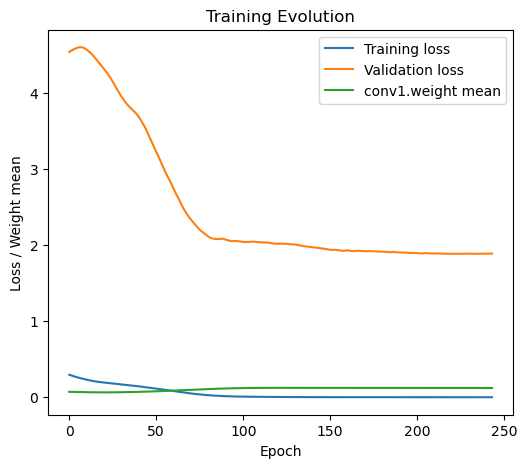

sample_strategy=random, Final sample shape: (1048576, 4)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 2
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.97887434, 1.13554818, 1.39741297, 1.27292277]), 'score': 0.6203895991131906, 'dim': 4, 'predicted_y': 11486.222, 'improvement_over_input_model': 4580.266, 'distance_to_best_input': 0.524597981956853, 'distance_to_real_best_input': 1.5770225753430536, 'best_input_x': array([0.803, 0.79 , 1.07 , 1.14 ]), 'best_input_pred': 6905.9556, 'real_best_x': array([0.030296, 1.089306, 1.301036, 0.017625]), 'real_best_y': 9832.0579380648}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.97887434, 1.13554818, 1.39741297, 1.27292277]), 'score': 0.6117319539514925, 'dim': 4, 'predicted_y': 11486.222, 'improvement_over_input_model': 4580.266, 'distance_to_best_input': 0.524597981956853, 'distance_to_real_best_input': 1.5770225753430536, 'best_input_x': array([0.803, 0.79 , 1.07 , 1.14 ]), 'best_input_pr

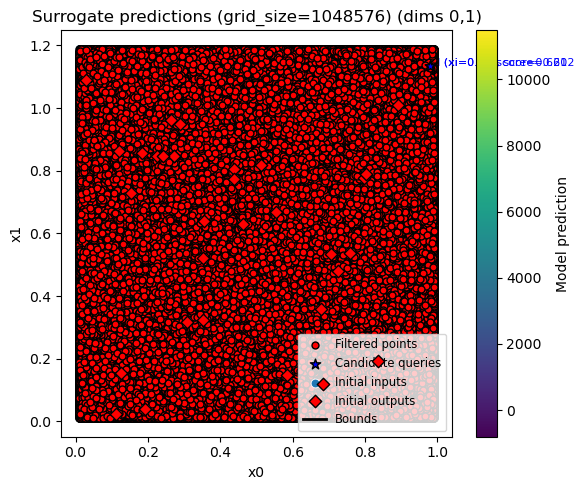

Saved dataframe to: results/run_2026-01-25 08-39-10/df_grid_1048576_stride4_None_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.97887434, 1.13554818, 1.39741297, 1.27292277]), 'score': 0.6203895991131906, 'dim': 4, 'predicted_y': 11486.222, 'improvement_over_input_model': 4580.266, 'distance_to_best_input': 0.524597981956853, 'distance_to_real_best_input': 1.5770225753430536, 'best_input_x': array([0.803, 0.79 , 1.07 , 1.14 ]), 'best_input_pred': 6905.9556, 'real_best_x': array([0.030296, 1.089306, 1.301036, 0.017625]), 'real_best_y': 9832.0579380648}
       var-1     var-2     var-3     var-4        yield   source  yield-scaled
0   0.030296  1.089306  1.301036  0.017625  9832.057938  week-12     10.000000
1   0.890679  1.008486  1.208429  0.458510  7827.226902  week-11      7.960924
2   0.803000  0.790000  1.070000  1.140000  7705.825094   week-9      7.837449
3   0.353188  0.520322  1.112618  1.186113  6717.039991   week-7      6.83

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))